# XGBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import xgboost as xgb
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


In [6]:
# Convert sparse matrices to dense for XGBoost
X_train_dense = X_train_tfidf.astype(np.float32)
X_test_dense = X_test_tfidf.astype(np.float32)
# Convert [1, 2] labels to [0, 1]
y_train = y_train.astype(int) - 1
y_test = y_test.astype(int) - 1

## Hyperparameter Tuning with RandomizedSearchCV

XGBoost is a powerful gradient boosting ensemble that can achieve state-of-the-art results.
However, it has many hyperparameters that interact in complex ways. We use `RandomizedSearchCV` to efficiently explore the parameter space.
RandomizedSearchCV is preferred over GridSearchCV because XGBoost has a very large hyperparameter space with many interactions.

> **Key Hyperparameters for XGBoost:**
> - `n_estimators`: Number of boosting rounds (trees in ensemble)
> - `max_depth`: Maximum tree depth (controls complexity)
> - `learning_rate`: Shrinkage parameter (step size for updates)
> - `subsample`: Fraction of samples for tree building
> - `colsample_bytree`: Fraction of features for tree building
> - `gamma`: Minimum loss reduction for split
> - `min_child_weight`: Minimum sum of weights for child
> - `reg_alpha`: L1 regularization (encourages sparsity)
> - `reg_lambda`: L2 regularization (weight decay)

In [9]:
# Define the hyperparameter search space for XGBoost
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],              # Number of boosting rounds
    'max_depth': [4, 5, 6, 7, 8],                          # Tree depth
    'learning_rate': [0.01, 0.05, 0.1, 0.15],              # Step size
    'subsample': [0.6, 0.7, 0.8, 0.9],                     # Row sampling
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],              # Feature sampling
    'gamma': [0, 0.1, 0.5, 1.0],                           # Minimum split loss
    'min_child_weight': [1, 3, 5, 7],                      # Minimum child weight
    'reg_alpha': [0, 0.1, 0.5, 1.0],                       # L1 regularization
    'reg_lambda': [0.5, 1.0, 1.5, 2.0],                    # L2 regularization
}
# Base estimator — XGBClassifier
base_xgb = xgb.XGBClassifier(random_state=42, n_jobs=10, eval_metric='logloss')
print("Starting RandomizedSearchCV for XGBoost...")
search_start = time.time()
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=20,                 # Test 20 random combinations (very large space)
    scoring='f1',              # Optimize for F1 (balanced metric for binary sentiment)
    cv=3,                      # 3-fold cross-validation on training data
    random_state=42,
    n_jobs=10,                 # Use all available cores
    verbose=2,
    refit=True                 # Refit best model on the full training set
)
random_search.fit(X_train_dense, y_train)
search_time = time.time() - search_start
print(f"\nRandomizedSearchCV completed in {search_time:.4f} seconds")

Starting RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

RandomizedSearchCV completed in 1713.9321 seconds


In [10]:
# Inspect the best hyperparameters found
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1-Score: {random_search.best_score_:.4f}")

Best Parameters:
  subsample: 0.9
  reg_lambda: 0.5
  reg_alpha: 1.0
  n_estimators: 300
  min_child_weight: 5
  max_depth: 8
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 0.7

Best CV F1-Score: 0.8526


In [11]:
# CV results summary — top 10 combinations
cv_results = pd.DataFrame(random_search.cv_results_)
top_results = (
    cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
)
print("Top 10 hyperparameter combinations (by F1):")
print(top_results.to_string(index=False))

Top 10 hyperparameter combinations (by F1):
                                                                                                                                                                           params  mean_test_score  std_test_score  rank_test_score
 {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}         0.852624        0.001130                1
     {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 250, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}         0.845293        0.000717                2
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.15, 'gamma': 0.5, 'colsample_bytree': 0.7}         0.841582        0.001453                3
  {'subsample': 0.7, 'reg_lambda': 1.0, 'reg

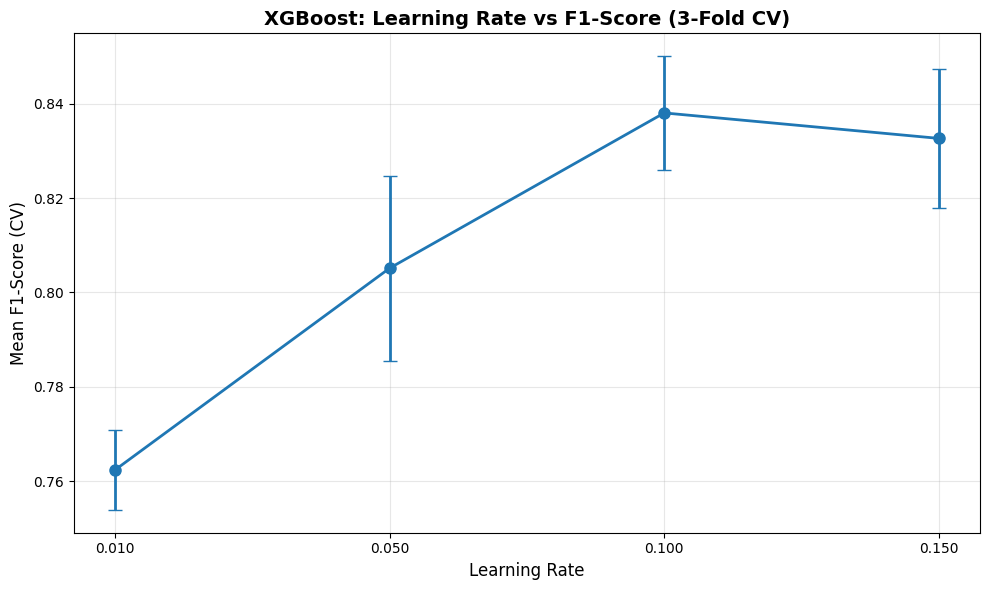


Learning Rate Performance Analysis:
 learning_rate     mean      std
          0.01 0.762377 0.008526
          0.05 0.805140 0.019612
          0.10 0.838037 0.012062
          0.15 0.832639 0.014812


In [ ]:
# Analyze the effect of learning_rate on F1-score
cv_df = pd.DataFrame(random_search.cv_results_)
cv_df['learning_rate'] = cv_df['params'].apply(lambda x: x['learning_rate'])
# Average performance by learning_rate
lr_performance = cv_df.groupby('learning_rate')['mean_test_score'].agg(['mean', 'std']).reset_index()
lr_performance = lr_performance.sort_values('learning_rate')
# Plot learning_rate sensitivity
plt.figure(figsize=(10, 6))
plt.errorbar(np.arange(len(lr_performance)), lr_performance['mean'], 
             yerr=lr_performance['std'], marker='o', capsize=5, linewidth=2, markersize=8)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('Mean F1-Score (CV)', fontsize=12)
plt.title('XGBoost: Learning Rate vs F1-Score (3-Fold CV)', fontsize=14, fontweight='bold')
plt.xticks(np.arange(len(lr_performance)), [f'{lr:.3f}' for lr in lr_performance['learning_rate']])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/02_results/xgb_learning_rate_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nLearning Rate Performance Analysis:")
print(lr_performance.to_string(index=False))

## XGBoost Model Training with Optimized Hyperparameters

We use the best parameters discovered via RandomizedSearchCV and train the final model on the **full** training set (already done by `refit=True` in `RandomizedSearchCV`).

In [13]:
# Retrieve the best estimator (already refit on the full training set)
xgb_classifier = random_search.best_estimator_
print(f"Final XGBoost Model trained with best hyperparameters:")
print(f"  Training set size: {X_train_dense.shape}")
print(f"  Number of Estimators: {xgb_classifier.n_estimators}")
print(f"  Max Depth: {xgb_classifier.max_depth}")
print(f"  Learning Rate: {xgb_classifier.learning_rate}")
print(f"  F1-Score (CV): {random_search.best_score_:.4f}")

Final XGBoost Model trained with best hyperparameters:
  Training set size: (79972, 100000)
  Number of Estimators: 300
  Max Depth: 8
  Learning Rate: 0.1
  F1-Score (CV): 0.8526


## Model Evaluation

In [14]:
# Make predictions
y_pred = xgb_classifier.predict(X_test_dense)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("XGBOOST CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {search_time:.4f} seconds")

XGBOOST CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8525
Precision: 0.8455
Recall:    0.8638
F1-Score:  0.8545
Training Time: 1713.9321 seconds


## Classification Report

In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85      9966
    Positive       0.85      0.86      0.85     10034

    accuracy                           0.85     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.85      0.85      0.85     20000



## Confusion Matrix Visualization

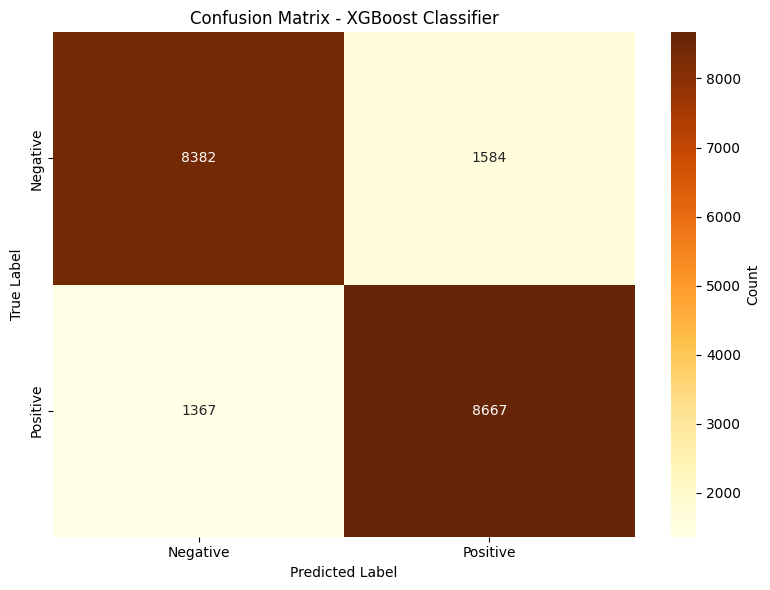

Confusion Matrix:
[[8382 1584]
 [1367 8667]]

True Negatives: 8382
False Positives: 1584
False Negatives: 1367
True Positives: 8667


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - XGBoost Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('docs/02_results/xgboost_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Importance

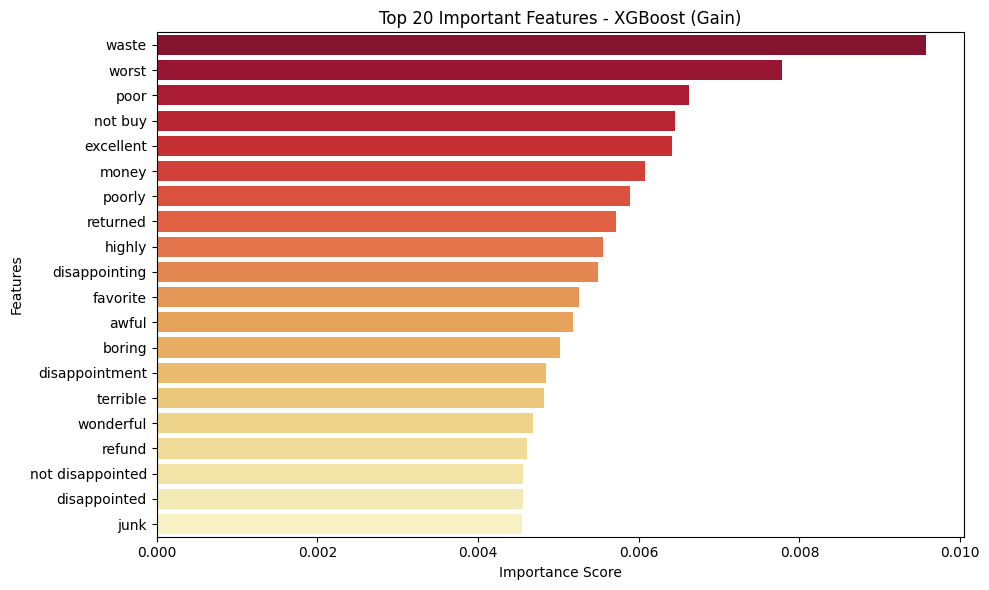


Top 20 Important Features:
         feature  importance
           waste    0.009571
           worst    0.007785
            poor    0.006622
         not buy    0.006457
       excellent    0.006417
           money    0.006083
          poorly    0.005897
        returned    0.005723
          highly    0.005561
   disappointing    0.005488
        favorite    0.005259
           awful    0.005181
          boring    0.005019
  disappointment    0.004840
        terrible    0.004826
       wonderful    0.004685
          refund    0.004612
not disappointed    0.004563
    disappointed    0.004559
            junk    0.004542


In [ ]:
# Get feature importance using gain (contributes most to model performance)
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = xgb_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='YlOrRd_r')
plt.title('Top 20 Important Features - XGBoost (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('docs/02_results/xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Learning Curve Analysis

In [18]:
# Get feature importance by different metrics
results = xgb_classifier.get_booster().get_score(importance_type='weight')
print(f"Number of times features are used in splits: {len(results)}")
print(f"\nTop 10 features by split count (weight):")
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)[:10]
for feature, count in sorted_results:
    print(f"  {feature}: {count}")

Number of times features are used in splits: 938

Top 10 features by split count (weight):
  f57594: 671.0
  f12797: 556.0
  f9409: 256.0
  f61026: 230.0
  f36547: 222.0
  f98265: 203.0
  f35210: 194.0
  f46804: 186.0
  f92288: 164.0
  f56990: 134.0


## Model Summary

In [19]:
print("XGBOOST MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Number of Estimators: {xgb_classifier.n_estimators}")
print(f"  - Max Depth: {xgb_classifier.max_depth}")
print(f"  - Learning Rate: {xgb_classifier.learning_rate}")
print(f"  - Subsample: {xgb_classifier.subsample}")
print(f"  - Colsample by Tree: {xgb_classifier.colsample_bytree}")
print(f"  - Gamma: {xgb_classifier.gamma}")
print(f"  - Min Child Weight: {xgb_classifier.min_child_weight}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {search_time:.4f} seconds")
print(f"\nModel Characteristics:")
print(f"  - Booster Type: gbtree")
print(f"  - Tree Method: auto")
print(f"  - Objective: binary:logistic")

XGBOOST MODEL SUMMARY

Model Parameters:
  - Number of Estimators: 300
  - Max Depth: 8
  - Learning Rate: 0.1
  - Subsample: 0.9
  - Colsample by Tree: 0.7
  - Gamma: 0.1
  - Min Child Weight: 5

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8525
  - Precision: 0.8455
  - Recall:    0.8638
  - F1-Score:  0.8545
  - Training Time: 1713.9321 seconds

Model Characteristics:
  - Booster Type: gbtree
  - Tree Method: auto
  - Objective: binary:logistic


## Saving the Model and Pipeline

In [20]:
save(model_base='data/models', model=xgb_classifier, model_name='12_xgboost_classifier.joblib')

Saved model 12_xgboost_classifier.joblib to data\models\12_xgboost_classifier.joblib


{'model': WindowsPath('data/models/12_xgboost_classifier.joblib')}